# Updated SIRV Model
## Reece Warner

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True

textwidth = 542.025

figwidth = textwidth/72.27
figheight = figwidth*0.61

## SIRV Model Introduction
At our last meeting, we came to a new assumption for modeling measles with an SIR-type model with a vaccination compartment.
This assumption being that for perfect effectiveness of the vaccine, there should be no change in proportion of vaccinated persons.
For anything other than perfect effectiveness, we should expect the vaccine compartment to increase.
We can accomplish this by use of a parameter $\sigma\in[0,1]$, where $\sigma=0$ corresponds to perfect effectiveness, and $\sigma=1$ corresponds to perfect ineffectiveness.

The compartments in our model are $S$, $I$, $R$, $V$, where each are a proportion of the total, constant population size $N$.
In other words, $S+I+R+V=1$.
Now, the model is given by
\begin{align*}
\dot{S} &= -\beta SI\\
\dot{I} &= \beta SI + \sigma\beta VI - \gamma I\\
\dot{R} &= \gamma I\\
\dot{V} &= -\sigma\beta VI,
\end{align*}
where $\beta,\gamma\geq0$ are the infectivity and recovery rates, respectively.
Note that for perfect effectiveness ($\sigma=0$), this model can be viewed as the simple SIR model, with $S+I+R=1-V_0$.

## SIRV Model Basic Reproduction Number
Recall that the basic reproduction number $\mathrm{R}_0$ is a thresholding quantity that-typically-determines if there an epidemic will occur.
The bifurcation occurs at $\mathrm{R}_0=1$, where $\mathrm{R}_0>1\implies$ an epidemic will persist, and $\mathrm{R}_0\leq1\implies$ an epidemic will not occur.
The biological meaning of this quantity is the number of secondary infections caused by a typical infective.

To calculate the basic reproduction number by use of the method of the next generation matrix, we first see that there is only one compartment in the SIRV model that holds infectives, namely $I$.
The number of new infections $F=\beta SI+ \sigma\beta VI$, and the number of recovered infectives is $N = \gamma I$.
Then, the basic reproduction number is simply
\begin{align*}
\mathrm{R}_0&=N^{-1}F\\
&=\frac{\beta}{\gamma}\left( S_0 + \sigma V_0 \right)\\
&=\frac{\beta}{\gamma}\left[ 1 + V_0\left(\sigma - 1 \right) \right].
\end{align*}
Note that, for perfect ineffectiveness, $\mathrm{R}_0=\frac{\beta S_0}{\gamma}$ is the basic reproduction number of the simple SIR model.

Looking at the basic reproduction of this model, we can see that it can be thought of as a function of the initial vaccinated population and vaccine effectiveness.
That way, we can determine the combination of vaccine effectivenses and proportion of vaccinated persons sufficient for an epidemic to not occur.
The initial vaccinated proportion for which we have $\mathrm{R}_0=1$ is determined by
\begin{align*}
\dot{I}&=0\\
I(\beta S + \sigma\beta V - \gamma) &= 0\\
\beta S_0 + \sigma\beta V_0 - \gamma &= 0\\
\sigma\beta V_0 &= \gamma - \beta S_0\\
\sigma\beta V_0 &= \gamma - \beta (1-V_0)\\
V_0(\sigma\beta -\beta) &= \gamma-\beta\\
V_0 &= \frac{\frac{\gamma}{\beta} - 1}{\sigma - 1}.
\end{align*}

## Modeling $\mathrm{R}_0(V_0,\sigma)$ with a heat map

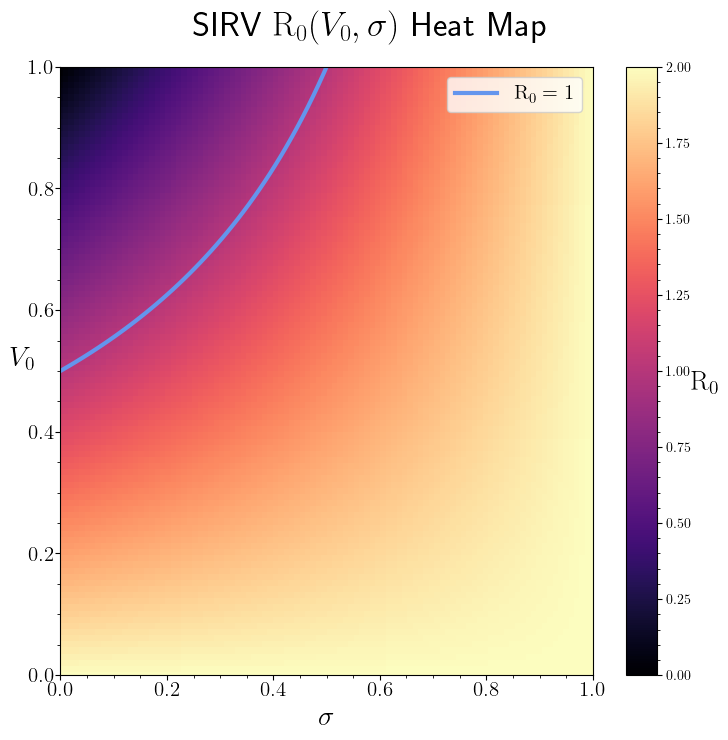

In [3]:
def R0(v0, s0, beta, gamma, sigma):
    return beta/gamma*(s0 + sigma*v0)

def V0(sigma, beta, gamma):
    return (gamma/beta - 1)/(sigma - 1)

beta = 0.4
gamma = 0.2
sigma = 0.4

num_points = 100

sigmas = np.linspace(0, 1.0, num_points)
v0s = np.linspace(0, 1.0, num_points)
SIG, V0s = np.meshgrid(sigmas, v0s)
R0s = beta/gamma*(1-V0s + SIG*V0s)

# for the R_0 = 1 level curve
V_sig = V0(sigmas[:-1], beta, gamma)
V_sig_trunc = V_sig[:51]
sigmas_trunc = sigmas[:51]

fig2, ax2 = plt.subplots(1,1, figsize = (figwidth, figwidth))

c = ax2.pcolormesh(SIG, V0s, R0s,cmap = 'magma', )

ax2.plot(sigmas_trunc, V_sig_trunc, color = 'cornflowerblue', linewidth = 3, label = r'$\mathrm{R}_0=1$')
ax2.legend(loc = 'upper right', fontsize = 15)

ax2.set_xlim(0, 1.0)
ax2.set_ylim(0, 1.0)
ax2.set_xticks(np.arange(0, 1.04, 1/20), minor = True)
ax2.set_yticks(np.arange(0, 1.04, 1/20), minor = True)
ax2.set_xlabel(r"$\sigma$", fontsize = 20)
ax2.set_ylabel(r"$V_{0}$", fontsize = 20, rotation = 0)
ax2.tick_params(axis = 'both', labelsize = 15, pad = 1)

# colorbar and formatting
cbar = fig2.colorbar(c, ax = ax2)
cbar_ax = cbar.ax
cbar.set_label(label = r'$\mathrm{R}_0$', rotation = 0, fontsize = 20, loc = 'center', labelpad = 10)
cbar.set_ticks(np.arange(0, 2.05, 0.05), minor = True)

fig2.suptitle(r"SIRV $\mathrm{R}_0(V_0, \sigma)$ Heat Map", fontsize = 25)
fig2.tight_layout()